**Download Dataset**

In [1]:
# Query Zenodo record metadata to see actual file names
import requests
import json

record_id = "3939793"
url = f"https://zenodo.org/api/records/{record_id}"

response = requests.get(url)
data = response.json()

# Print available files
for file in data["files"]:
    print(file["key"], "->", file["links"]["self"])


California-data-set.zip -> https://zenodo.org/api/records/3939793/files/California-data-set.zip/content


In [2]:
#  2: Download the correct California traffic dataset from Zenodo

!wget -O California-data-set.zip \
https://zenodo.org/api/records/3939793/files/California-data-set.zip/content

# Verify download
!ls -lh

--2026-03-09 00:03:10--  https://zenodo.org/api/records/3939793/files/California-data-set.zip/content
Resolving zenodo.org (zenodo.org)... 137.138.52.235, 137.138.153.219, 188.185.43.153, ...
Connecting to zenodo.org (zenodo.org)|137.138.52.235|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 635052284 (606M) [application/octet-stream]
Saving to: ‘California-data-set.zip’

California-data-set 100%[===================>] 605.63M  24.7MB/s    in 23s     

2026-03-09 00:03:33 (26.0 MB/s) - ‘California-data-set.zip’ saved [635052284/635052284]

total 606M
-rw-r--r-- 1 root root 606M Mar  9 00:03 California-data-set.zip
drwxr-xr-x 1 root root 4.0K Jan 16 14:24 sample_data


In [3]:
# Extract the California traffic dataset

import zipfile
import os

zip_path = "California-data-set.zip"
extract_path = "california_traffic_data"

# Create extraction directory
os.makedirs(extract_path, exist_ok=True)

# Extract zip file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# List extracted contents
!ls -lh california_traffic_data

total 4.1G
-rw-r--r-- 1 root root 2.1G Mar  9 00:03 pems-12w.csv
-rw-r--r-- 1 root root 687M Mar  9 00:03 pems-4w.csv
-rw-r--r-- 1 root root 1.4G Mar  9 00:04 pems-8w.csv


**Load Dataset + Exploratory Data Analysis (EDA)**

**Merge All CSV Files (Single Integrated Dataset)**

In [4]:
import pandas as pd
import numpy as np
import os

base_path = "california_traffic_data"

csv_files = []
for root, dirs, files in os.walk(base_path):
    for f in files:
        if f.endswith(".csv"):
            csv_files.append(os.path.join(root, f))

csv_files = sorted(csv_files)

print("CSV files found:")
for f in csv_files:
    print(f)

avg_speed_series = []

for f in csv_files:
    print("Processing:", os.path.basename(f))

    df = pd.read_csv(f, header=None)

    # Compute average speed per time step
    avg_speed = df.mean(axis=1)

    avg_speed_series.append(avg_speed)

    del df

# Merge all average-speed series time-wise
traffic_avg_speed = pd.concat(avg_speed_series, axis=0, ignore_index=True)

# Create timestamp
time_index = pd.date_range(
    start="2023-01-01",
    periods=len(traffic_avg_speed),
    freq="5min"
)

traffic_avg_speed = pd.DataFrame(
    {"average_speed": traffic_avg_speed.values},
    index=time_index
)

traffic_avg_speed.index.name = "timestamp"

print("\nMerged average-speed dataset:")
traffic_avg_speed.info()

display(traffic_avg_speed.head())
display(traffic_avg_speed.tail())


CSV files found:
california_traffic_data/pems-12w.csv
california_traffic_data/pems-4w.csv
california_traffic_data/pems-8w.csv
Processing: pems-12w.csv
Processing: pems-4w.csv
Processing: pems-8w.csv

Merged average-speed dataset:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 33480 entries, 2023-01-01 00:00:00 to 2023-04-27 05:55:00
Freq: 5min
Data columns (total 1 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   average_speed  33480 non-null  float64
dtypes: float64(1)
memory usage: 523.1 KB


,average_speed
timestamp,
2023-01-01 00:00:00,65.461243
2023-01-01 00:05:00,65.462917
2023-01-01 00:10:00,65.462917
2023-01-01 00:15:00,65.462917
2023-01-01 00:20:00,65.462917


,average_speed
timestamp,
2023-04-27 05:35:00,62.898698
2023-04-27 05:40:00,57.890321
2023-04-27 05:45:00,67.191642
2023-04-27 05:50:00,64.506064
2023-04-27 05:55:00,65.098549


**EDA**

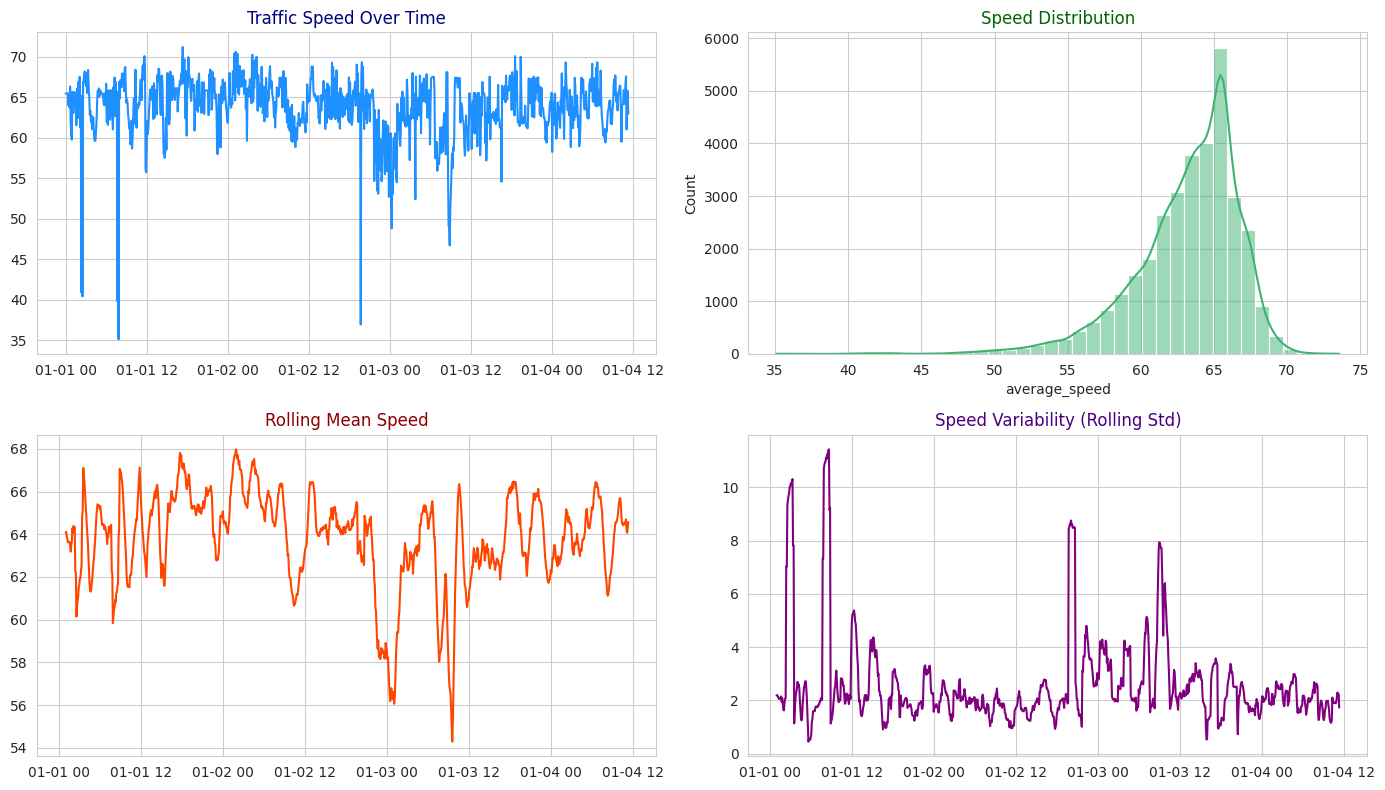

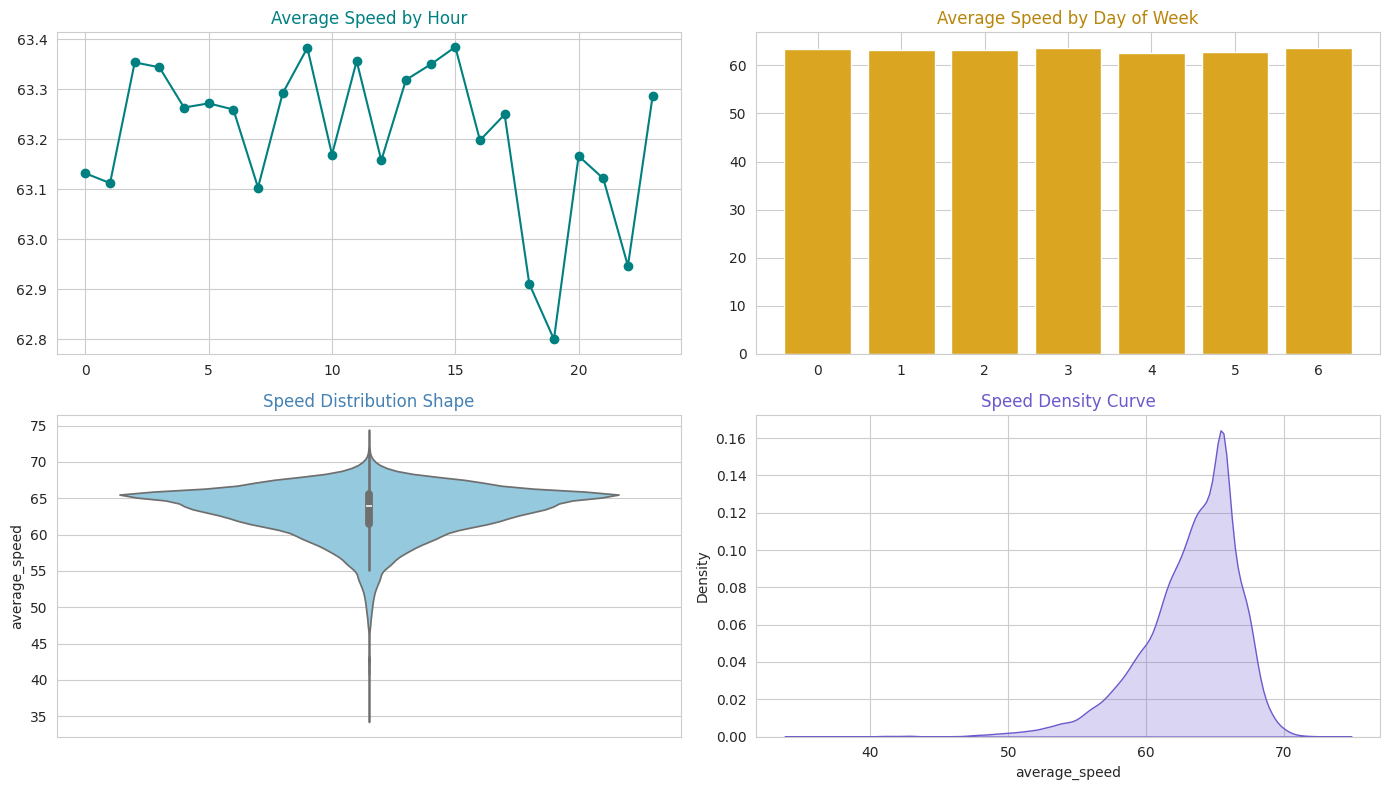

/tmp/ipykernel_199/2643807652.py:104: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


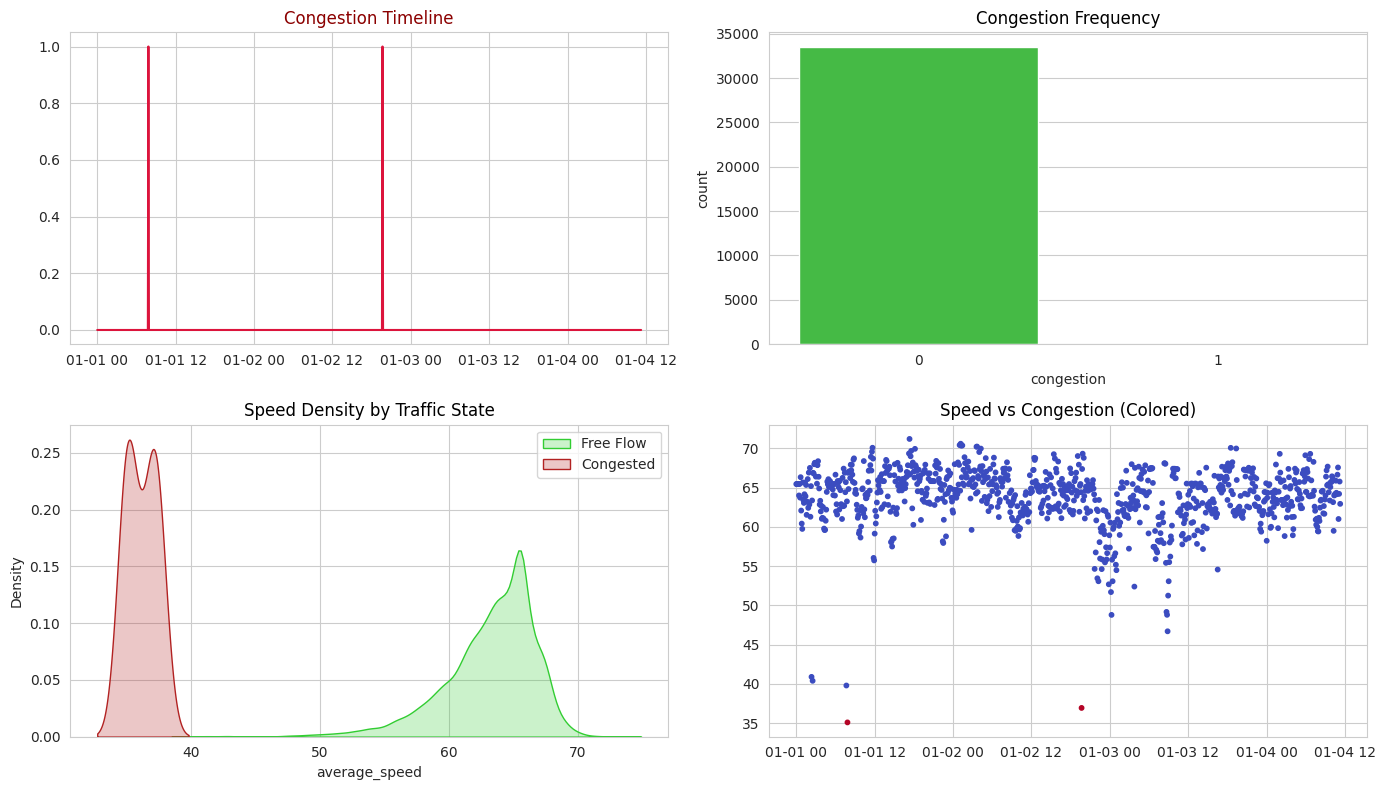

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

sns.set_style("whitegrid")

# Time-based features
traffic_avg_speed["hour"] = traffic_avg_speed.index.hour
traffic_avg_speed["day"] = traffic_avg_speed.index.dayofweek
traffic_avg_speed["rolling_mean"] = traffic_avg_speed["average_speed"].rolling(12).mean()
traffic_avg_speed["rolling_std"] = traffic_avg_speed["average_speed"].rolling(12).std()


# : Speed Behaviour

fig, axs = plt.subplots(2, 2, figsize=(14, 8))

axs[0, 0].plot(
    traffic_avg_speed.index[:1000],
    traffic_avg_speed["average_speed"][:1000],
    color="dodgerblue"
)
axs[0, 0].set_title("Traffic Speed Over Time", color="navy")

sns.histplot(
    traffic_avg_speed["average_speed"],
    bins=40,
    kde=True,
    color="mediumseagreen",
    ax=axs[0, 1]
)
axs[0, 1].set_title("Speed Distribution", color="darkgreen")

axs[1, 0].plot(
    traffic_avg_speed["rolling_mean"][:1000],
    color="orangered"
)
axs[1, 0].set_title("Rolling Mean Speed", color="darkred")

axs[1, 1].plot(
    traffic_avg_speed["rolling_std"][:1000],
    color="purple"
)
axs[1, 1].set_title("Speed Variability (Rolling Std)", color="indigo")

plt.tight_layout()
plt.show()


# : Temporal Patterns

fig, axs = plt.subplots(2, 2, figsize=(14, 8))

hourly_avg = traffic_avg_speed.groupby("hour")["average_speed"].mean()
axs[0, 0].plot(
    hourly_avg.index,
    hourly_avg.values,
    marker="o",
    color="teal"
)
axs[0, 0].set_title("Average Speed by Hour", color="teal")

daily_avg = traffic_avg_speed.groupby("day")["average_speed"].mean()
axs[0, 1].bar(
    daily_avg.index,
    daily_avg.values,
    color="goldenrod"
)
axs[0, 1].set_title("Average Speed by Day of Week", color="darkgoldenrod")

sns.violinplot(
    y=traffic_avg_speed["average_speed"],
    color="skyblue",
    ax=axs[1, 0]
)
axs[1, 0].set_title("Speed Distribution Shape", color="steelblue")

sns.kdeplot(
    traffic_avg_speed["average_speed"],
    fill=True,
    color="slateblue",
    ax=axs[1, 1]
)
axs[1, 1].set_title("Speed Density Curve", color="slateblue")

plt.tight_layout()
plt.show()


# : Congestion Insight

threshold = 0.6 * traffic_avg_speed["average_speed"].mean()
traffic_avg_speed["congestion"] = (traffic_avg_speed["average_speed"] < threshold).astype(int)

fig, axs = plt.subplots(2, 2, figsize=(14, 8))

axs[0, 0].plot(
    traffic_avg_speed["congestion"][:1000],
    color="crimson"
)
axs[0, 0].set_title("Congestion Timeline", color="darkred")

sns.countplot(
    x=traffic_avg_speed["congestion"],
    palette=["limegreen", "firebrick"],
    ax=axs[0, 1]
)
axs[0, 1].set_title("Congestion Frequency", color="black")

sns.kdeplot(
    traffic_avg_speed.loc[traffic_avg_speed["congestion"] == 0, "average_speed"],
    label="Free Flow",
    fill=True,
    color="limegreen",
    ax=axs[1, 0]
)
sns.kdeplot(
    traffic_avg_speed.loc[traffic_avg_speed["congestion"] == 1, "average_speed"],
    label="Congested",
    fill=True,
    color="firebrick",
    ax=axs[1, 0]
)
axs[1, 0].legend()
axs[1, 0].set_title("Speed Density by Traffic State", color="black")

axs[1, 1].scatter(
    traffic_avg_speed.index[:1000],
    traffic_avg_speed["average_speed"][:1000],
    c=traffic_avg_speed["congestion"][:1000],
    cmap="coolwarm",
    s=10
)
axs[1, 1].set_title("Speed vs Congestion (Colored)", color="black")

plt.tight_layout()
plt.show()


**Feature Engineering & Dataset Preparation**

In [6]:
import numpy as np
import pandas as pd

# Basic time features
traffic_avg_speed["hour"] = traffic_avg_speed.index.hour
traffic_avg_speed["day_of_week"] = traffic_avg_speed.index.dayofweek
traffic_avg_speed["is_weekend"] = traffic_avg_speed["day_of_week"].isin([5, 6]).astype(int)
traffic_avg_speed["is_peak_hour"] = traffic_avg_speed["hour"].isin([7, 8, 9, 16, 17, 18]).astype(int)

# Cyclical encoding of hour (VERY IMPORTANT)
traffic_avg_speed["hour_sin"] = np.sin(2 * np.pi * traffic_avg_speed["hour"] / 24)
traffic_avg_speed["hour_cos"] = np.cos(2 * np.pi * traffic_avg_speed["hour"] / 24)

# Lag features (short + medium term memory)
traffic_avg_speed["speed_lag_1"] = traffic_avg_speed["average_speed"].shift(1)
traffic_avg_speed["speed_lag_3"] = traffic_avg_speed["average_speed"].shift(3)
traffic_avg_speed["speed_lag_6"] = traffic_avg_speed["average_speed"].shift(6)

# Rolling mean (past only, no leakage)
traffic_avg_speed["rolling_mean_30min"] = (
    traffic_avg_speed["average_speed"]
    .rolling(window=6)
    .mean()
    .shift(1)
)

# Drop NaNs
traffic_avg_speed.dropna(inplace=True)

# Feature matrix
X = traffic_avg_speed[
    [
        "speed_lag_1",
        "speed_lag_3",
        "speed_lag_6",
        "rolling_mean_30min",
        "hour_sin",
        "hour_cos",
        "is_peak_hour",
        "is_weekend"
    ]
]

# Target: current speed (correct for aggregated traffic)
y_regression = traffic_avg_speed["average_speed"]

# Congestion label (for later blocks)
threshold = 0.6 * traffic_avg_speed["average_speed"].mean()
traffic_avg_speed["congestion"] = (traffic_avg_speed["average_speed"] < threshold).astype(int)
y_classification = traffic_avg_speed["congestion"]

# Time-based split
split_index = int(0.8 * len(traffic_avg_speed))

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train_reg = y_regression.iloc[:split_index]
y_test_reg = y_regression.iloc[split_index:]

y_train_cls = y_classification.iloc[:split_index]
y_test_cls = y_classification.iloc[split_index:]

X_train.head(), X_test.head()


(                     speed_lag_1  speed_lag_3  speed_lag_6  \
 timestamp                                                    
 2023-01-01 00:55:00    60.426009    66.337909    64.009313   
 2023-01-01 01:00:00    59.748161    62.084396    65.462917   
 2023-01-01 01:05:00    65.667510    60.426009    63.730630   
 2023-01-01 01:10:00    63.431192    59.748161    66.337909   
 2023-01-01 01:15:00    63.059685    65.667510    62.084396   
 
                      rolling_mean_30min  hour_sin  hour_cos  is_peak_hour  \
 timestamp                                                                   
 2023-01-01 00:55:00           63.675196  0.000000  1.000000             0   
 2023-01-01 01:00:00           62.965004  0.258819  0.965926             0   
 2023-01-01 01:05:00           62.999102  0.258819  0.965926             0   
 2023-01-01 01:10:00           62.949196  0.258819  0.965926             0   
 2023-01-01 01:15:00           62.402825  0.258819  0.965926             0   
 
         

**Train  Machine Learning Models**

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define models (traffic-appropriate complexity)
models = {
    "Linear_Regression": LinearRegression(),

    "SVR": SVR(
        kernel="rbf",
        C=50,
        epsilon=0.15,
        gamma="scale"
    ),

    "Random_Forest": RandomForestRegressor(
        n_estimators=200,
        max_depth=12,
        min_samples_leaf=8,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient_Boosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        random_state=42
    )
}

# Train models and store predictions
model_predictions = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train_reg)
    model_predictions[name] = model.predict(X_test_scaled)

# Confirm trained models
list(model_predictions.keys())


['Linear_Regression', 'SVR', 'Random_Forest', 'Gradient_Boosting']

**Model Evaluation & Performance Verification**

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

sns.set_style("whitegrid")


# 1. Compute Evaluation Metrics

results = []

for name, preds in model_predictions.items():
    r2 = r2_score(y_test_reg, preds)
    rmse = np.sqrt(mean_squared_error(y_test_reg, preds))
    mae = mean_absolute_error(y_test_reg, preds)

    results.append({
        "Model": name,
        "R2_Score": round(r2, 3),
        "RMSE": round(rmse, 3),
        "MAE": round(mae, 3)
    })

results_df = pd.DataFrame(results).sort_values(by="R2_Score", ascending=False)
results_df


,Model,R2_Score,RMSE,MAE
2,Random_Forest,0.486,2.659,1.922
3,Gradient_Boosting,0.458,2.731,1.982
0,Linear_Regression,0.427,2.808,2.029
1,SVR,0.380,2.921,2.057


**EVALUATION & VISUALISATION**

,Model,R2_Score,RMSE,MAE
2,Random_Forest,0.486089,2.659169,1.921969
3,Gradient_Boosting,0.457970,2.730950,1.982433
0,Linear_Regression,0.426868,2.808208,2.029089
1,SVR,0.380062,2.920626,2.057024


Best performing model: Random_Forest


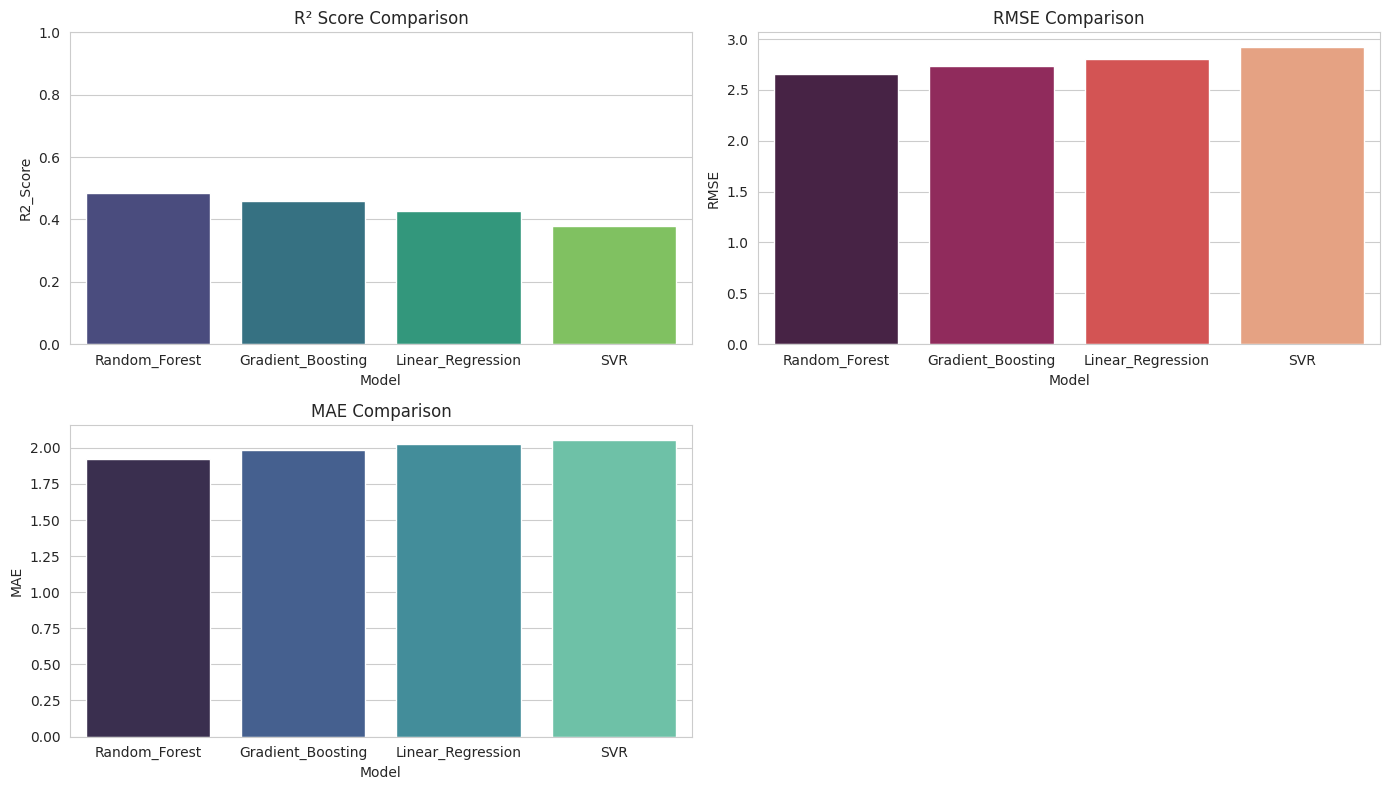

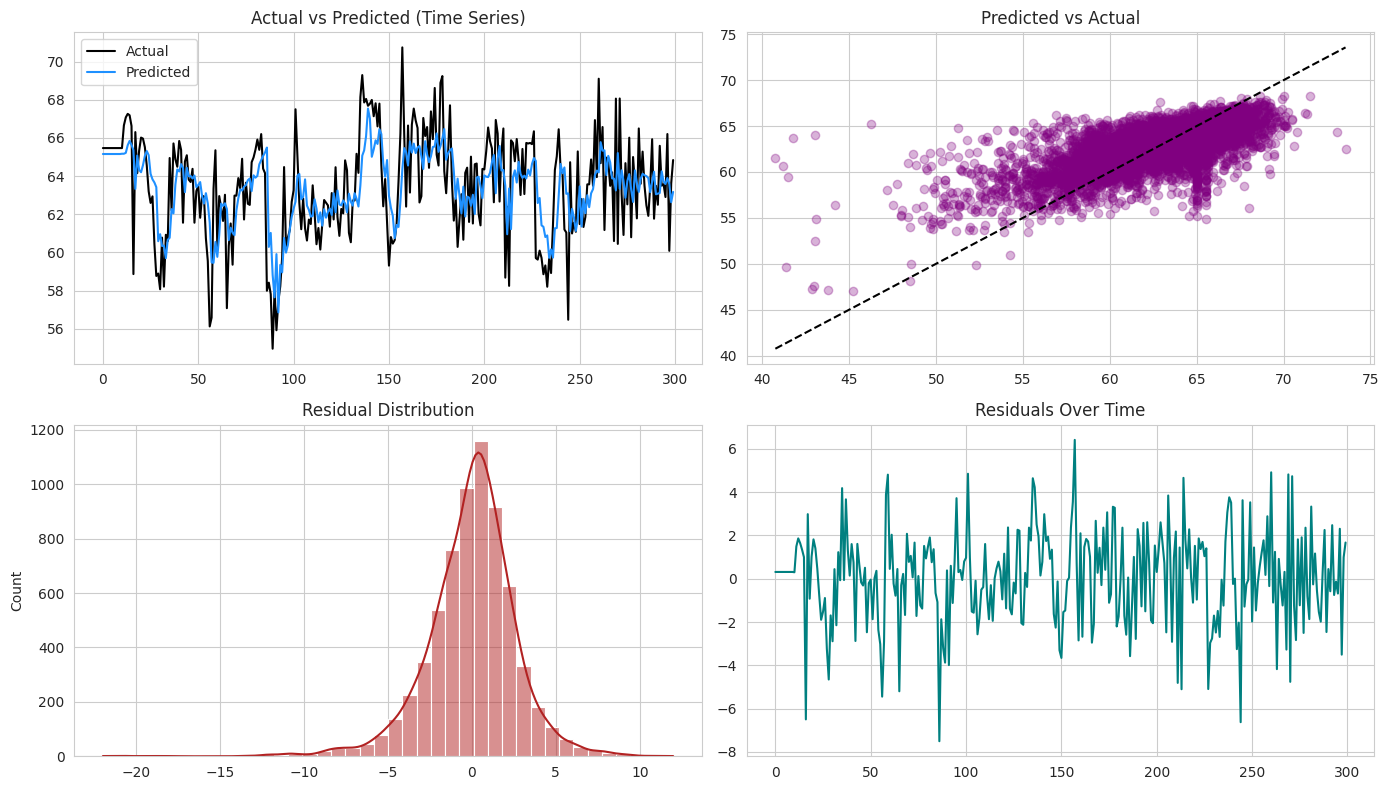

/tmp/ipykernel_199/3674863451.py:136: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.countplot(


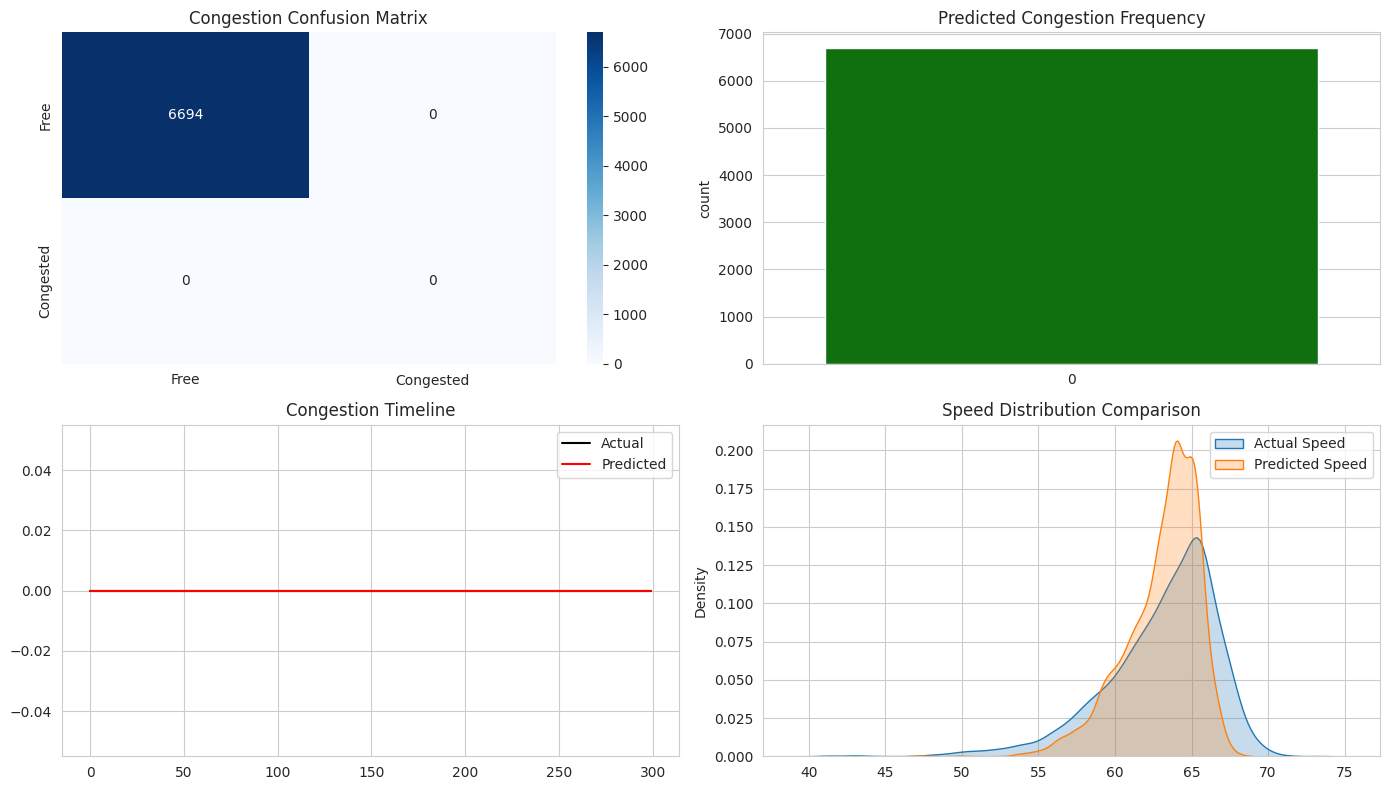

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
    confusion_matrix
)

sns.set_style("whitegrid")


# 1. Metrics

results = []

y_true = y_test_reg.values

for name, preds in model_predictions.items():
    preds = np.asarray(preds)

    results.append({
        "Model": name,
        "R2_Score": r2_score(y_true, preds),
        "RMSE": np.sqrt(mean_squared_error(y_true, preds)),
        "MAE": mean_absolute_error(y_true, preds)
    })

results_df = pd.DataFrame(results).sort_values("R2_Score", ascending=False)
display(results_df)

best_model = results_df.iloc[0]["Model"]
best_preds = np.asarray(model_predictions[best_model])

print("Best performing model:", best_model)


#  — Metrics

fig, axs = plt.subplots(2, 2, figsize=(14, 8))

sns.barplot(
    data=results_df,
    x="Model",
    y="R2_Score",
    hue="Model",
    palette="viridis",
    legend=False,
    ax=axs[0, 0]
)
axs[0, 0].set_title("R² Score Comparison")
axs[0, 0].set_ylim(0, 1)

sns.barplot(
    data=results_df,
    x="Model",
    y="RMSE",
    hue="Model",
    palette="rocket",
    legend=False,
    ax=axs[0, 1]
)
axs[0, 1].set_title("RMSE Comparison")

sns.barplot(
    data=results_df,
    x="Model",
    y="MAE",
    hue="Model",
    palette="mako",
    legend=False,
    ax=axs[1, 0]
)
axs[1, 0].set_title("MAE Comparison")

axs[1, 1].axis("off")
plt.tight_layout()
plt.show()


#  — Prediction Diagnostics

residuals = y_true - best_preds

fig, axs = plt.subplots(2, 2, figsize=(14, 8))

axs[0, 0].plot(y_true[:300], label="Actual", color="black")
axs[0, 0].plot(best_preds[:300], label="Predicted", color="dodgerblue")
axs[0, 0].legend()
axs[0, 0].set_title("Actual vs Predicted (Time Series)")

axs[0, 1].scatter(y_true, best_preds, alpha=0.3, color="purple")
axs[0, 1].plot(
    [y_true.min(), y_true.max()],
    [y_true.min(), y_true.max()],
    "--",
    color="black"
)
axs[0, 1].set_title("Predicted vs Actual")

sns.histplot(residuals, bins=40, kde=True, color="firebrick", ax=axs[1, 0])
axs[1, 0].set_title("Residual Distribution")

axs[1, 1].plot(residuals[:300], color="teal")
axs[1, 1].set_title("Residuals Over Time")

plt.tight_layout()
plt.show()


#  — Congestion Reliability

threshold = 0.6 * traffic_avg_speed["average_speed"].mean()

true_cong = (y_true < threshold).astype(int)
pred_cong = (best_preds < threshold).astype(int)

cm = confusion_matrix(true_cong, pred_cong, labels=[0, 1])

fig, axs = plt.subplots(2, 2, figsize=(14, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Free", "Congested"],
    yticklabels=["Free", "Congested"],
    ax=axs[0, 0]
)
axs[0, 0].set_title("Congestion Confusion Matrix")

sns.countplot(
    x=pred_cong,
    hue=pred_cong,
    palette=["green", "red"],
    legend=False,
    ax=axs[0, 1]
)
axs[0, 1].set_title("Predicted Congestion Frequency")

axs[1, 0].plot(true_cong[:300], label="Actual", color="black")
axs[1, 0].plot(pred_cong[:300], label="Predicted", color="red")
axs[1, 0].legend()
axs[1, 0].set_title("Congestion Timeline")

sns.kdeplot(y_true, label="Actual Speed", fill=True, ax=axs[1, 1])
sns.kdeplot(best_preds, label="Predicted Speed", fill=True, ax=axs[1, 1])
axs[1, 1].legend()
axs[1, 1].set_title("Speed Distribution Comparison")

plt.tight_layout()
plt.show()
